In [1]:
from all_imports import *

In [2]:
# 1. Merge Order Items (contains shipping_limit_date) with Orders (contains actual carrier handoff)
seller_base = orderItems_df[['order_id', 'order_item_id', 'seller_id', 'product_id', 'shipping_limit_date']].merge(
    orders_df[['order_id', 'order_delivered_carrier_date']], 
    on='order_id', 
    how='inner'
)

# 2. Attach average review score per order
order_reviews_agg = orderReviews_df.groupby('order_id')['review_score'].mean().reset_index()
seller_base = seller_base.merge(order_reviews_agg, on='order_id', how='left')

# 3. Attach Product Category
seller_base = seller_base.merge(products_df[['product_id', 'product_category_name']], on='product_id', how='left')
seller_base = seller_base.merge(productCategoryNameTranslation_df, on='product_category_name', how='left')

# 4. Calculate Seller Dispatch Delay
# Convert to datetime
seller_base['shipping_limit_date'] = pd.to_datetime(seller_base['shipping_limit_date'])
seller_base['order_delivered_carrier_date'] = pd.to_datetime(seller_base['order_delivered_carrier_date'])

# Positive number = Seller was LATE handing it to the carrier
seller_base['dispatch_delta_days'] = (
    seller_base['order_delivered_carrier_date'] - seller_base['shipping_limit_date']
).dt.total_seconds() / (24 * 3600)

seller_base['is_dispatch_late'] = seller_base['dispatch_delta_days'] > 0

# 5. Aggregate to the Seller Level
# We use a lambda to find the seller's most frequent category (their "primary" category)
seller_stats = seller_base.groupby('seller_id').agg(
    total_items_sold=('order_item_id', 'count'),
    late_dispatch_rate=('is_dispatch_late', 'mean'), # Mean of a boolean gives the percentage
    avg_review_score=('review_score', 'mean'),
    primary_category=('product_category_name_english', lambda x: x.mode()[0] if not x.mode().empty else 'Unknown')
).reset_index()

# Convert rate to percentage
seller_stats['late_dispatch_rate'] *= 100

# 6. Filter for established sellers (e.g., >30 items sold) to remove noise from 1-off sellers
established_sellers = seller_stats[seller_stats['total_items_sold'] >= 30].copy()

C:\Users\BACI\AppData\Local\Temp\ipykernel_22924\839124641.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.violinplot(


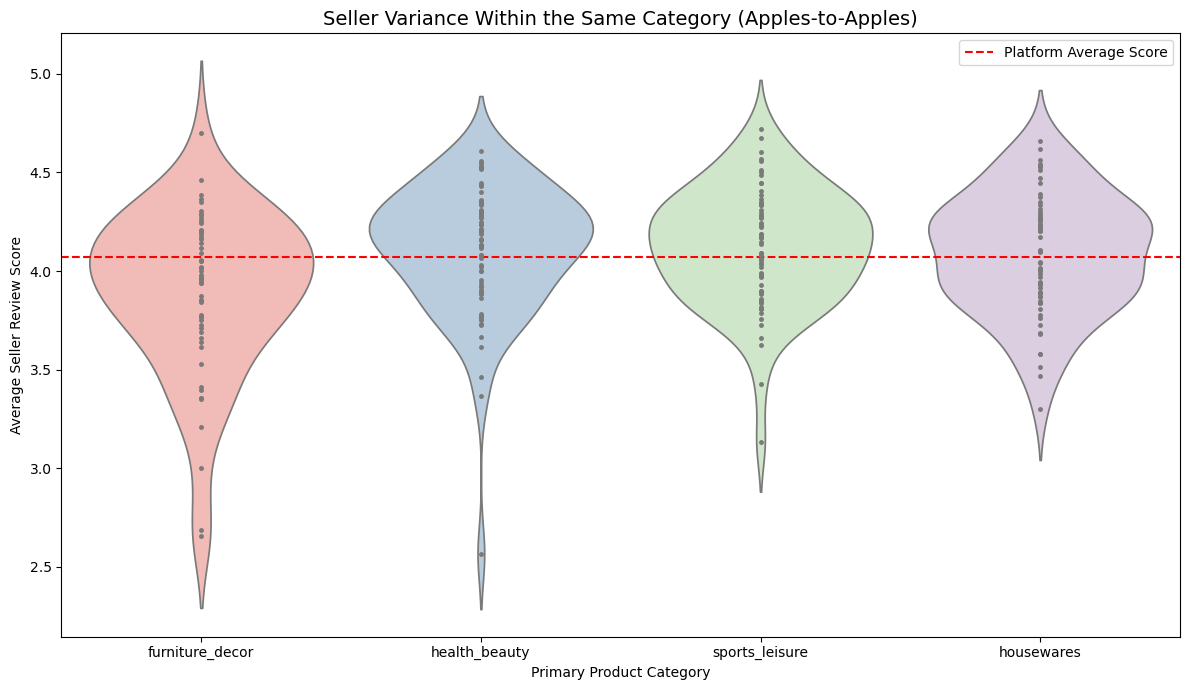

In [3]:
# Identify the top 4 categories by number of established sellers
top_categories = established_sellers['primary_category'].value_counts().nlargest(4).index
plot_data = established_sellers[established_sellers['primary_category'].isin(top_categories)]

plt.figure(figsize=(12, 7))
sns.violinplot(
    data=plot_data, 
    x='primary_category', 
    y='avg_review_score', 
    inner="point", # Shows individual sellers as dots inside the violin
    palette="Pastel1"
)

plt.axhline(established_sellers['avg_review_score'].mean(), color='red', linestyle='--', label='Platform Average Score')

plt.title('Seller Variance Within the Same Category (Apples-to-Apples)', fontsize=14)
plt.xlabel('Primary Product Category')
plt.ylabel('Average Seller Review Score')
plt.legend()
plt.tight_layout()
plt.show()

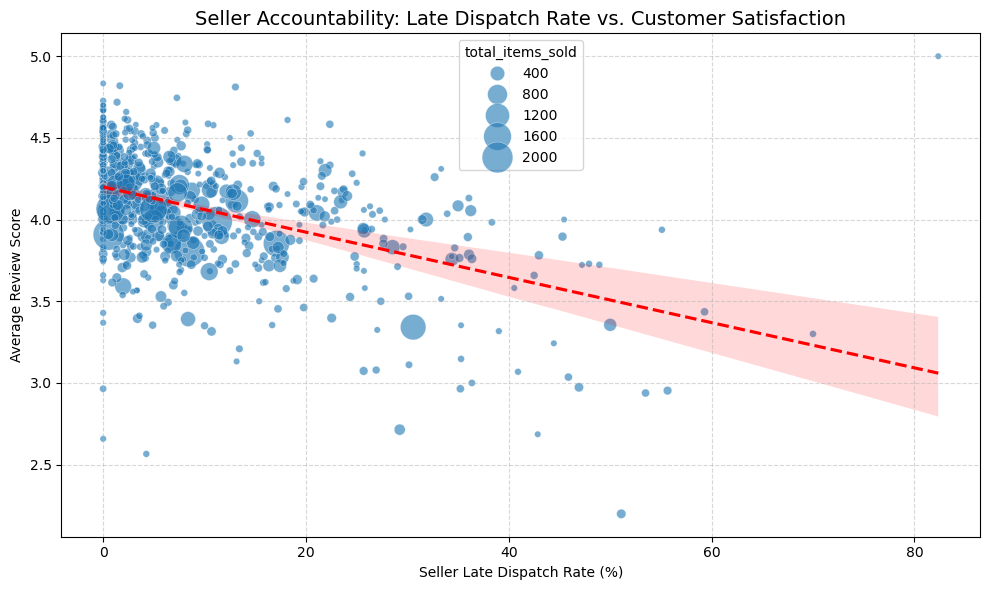

In [4]:
plt.figure(figsize=(10, 6))

# Plot Dispatch Rate vs Score
sns.scatterplot(
    data=established_sellers, 
    x='late_dispatch_rate', 
    y='avg_review_score', 
    size='total_items_sold',
    sizes=(20, 500),
    alpha=0.6,
    color='#1f77b4'
)

# Add a trendline using seaborn's regplot (overlaying it)
sns.regplot(
    data=established_sellers, 
    x='late_dispatch_rate', 
    y='avg_review_score', 
    scatter=False, 
    color='red', 
    line_kws={"linestyle": "--"}
)

plt.title('Seller Accountability: Late Dispatch Rate vs. Customer Satisfaction', fontsize=14)
plt.xlabel('Seller Late Dispatch Rate (%)')
plt.ylabel('Average Review Score')
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

--- Seller Performance Tiers ---


,performance_tier,seller_count,avg_score,avg_late_dispatch_rate
0,Bottom 20%,138,3.545485,17.591167
1,Lower 20%,138,3.936255,10.826072
2,Middle 20%,137,4.112375,8.414254
3,Top 20%,138,4.266176,5.317127
4,Top 10% (Elite),138,4.495148,4.292741


C:\Users\BACI\AppData\Local\Temp\ipykernel_22924\1595193603.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=tier_analysis, x='performance_tier', y='avg_late_dispatch_rate', palette='Reds')


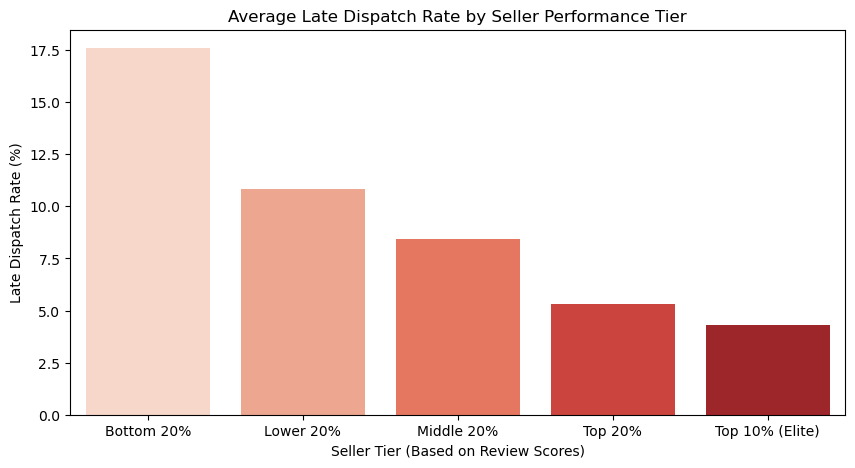

In [5]:
# Rank sellers into 5 tiers based on their review score
established_sellers['performance_tier'] = pd.qcut(
    established_sellers['avg_review_score'], 
    q=5, 
    labels=['Bottom 20%', 'Lower 20%', 'Middle 20%', 'Top 20%', 'Top 10% (Elite)']
)

tier_analysis = established_sellers.groupby('performance_tier', observed=False).agg(
    seller_count=('seller_id', 'count'),
    avg_score=('avg_review_score', 'mean'),
    avg_late_dispatch_rate=('late_dispatch_rate', 'mean')
).reset_index()

print("--- Seller Performance Tiers ---")
display(tier_analysis)

# Optional: Quick bar chart of the result
plt.figure(figsize=(10, 5))
sns.barplot(data=tier_analysis, x='performance_tier', y='avg_late_dispatch_rate', palette='Reds')
plt.title('Average Late Dispatch Rate by Seller Performance Tier')
plt.xlabel('Seller Tier (Based on Review Scores)')
plt.ylabel('Late Dispatch Rate (%)')
plt.show()